# Task 1-3

In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras import layers
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam, SGD, RMSprop

import matplotlib.pyplot as plt

from tqdm.keras import TqdmCallback
from tensorflow.keras.callbacks import EarlyStopping

## Preprocessing

In [2]:
# Load the dataset
df = pd.read_csv("hf://datasets/scikit-learn/auto-mpg/auto-mpg.csv")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
# Display basic info
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    object 
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    object 
dtypes: float64(3), int64(4), object(2)
memory usage: 28.1+ KB
None


In [4]:
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [5]:
# Convert 'horsepower' column to numeric, coercing errors to NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Fill NaN values with the mean of the column
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

# Now convert the 'horsepower' column to integers
df['horsepower'] = df['horsepower'].astype(int)

Convert origin column to one hot encoded columns

In [6]:
print(df.columns)

origin = df.pop('origin')

df['USA'] = (origin == 1)*1.0
df['Europe'] = (origin == 2)*1.0
df['Japan'] = (origin == 3)*1.0
df.tail()

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='object')


,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,car name,USA,Europe,Japan
393,27.0,4,140.0,86,2790,15.6,82,ford mustang gl,1.0,0.0,0.0
394,44.0,4,97.0,52,2130,24.6,82,vw pickup,0.0,1.0,0.0
395,32.0,4,135.0,84,2295,11.6,82,dodge rampage,1.0,0.0,0.0
396,28.0,4,120.0,79,2625,18.6,82,ford ranger,1.0,0.0,0.0
397,31.0,4,119.0,82,2720,19.4,82,chevy s-10,1.0,0.0,0.0


In [7]:
# Get the number of unique car names
num_unique_cars = df['car name'].nunique()

print(f"There are {num_unique_cars} unique car names in the dataset.")

# Drop car name since there are very less similar cars
df = df.drop(columns=['car name'])

There are 305 unique car names in the dataset.


## Model Training

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


0epoch [00:00, ?epoch/s]

0batch [00:00, ?batch/s]

Test Loss (MSE): 8.917959213256836
Test MAE: 2.3099043369293213
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


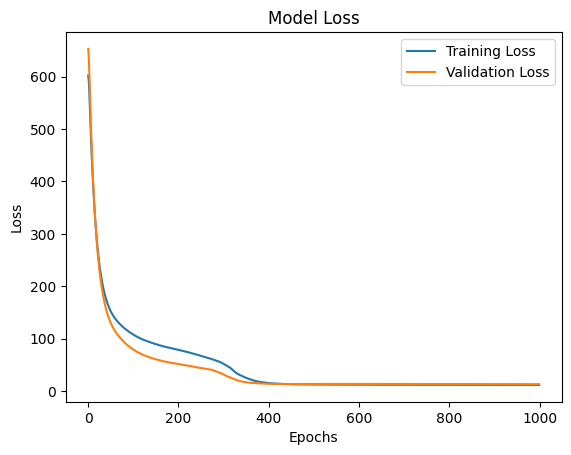

In [17]:
X = df.drop(columns=['mpg'])  # Assuming 'mpg' is the target variable
X = X.astype(float)
y = df['mpg']
y = y.astype(float)

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features using StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Define the Keras model
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
#     Dense(32, activation='relu'),
#     Dense(1)  # Linear activation for regression
# ])
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True  # Restore model weights from the epoch with the best value of the monitored quantity
)

model= Sequential()
model.add(Dense(1, input_shape=(X_train.shape[1],), activation='relu', ))

# Compile the model
model.compile(optimizer=SGD(learning_rate=0.0001), loss='mse', metrics=['mae'])

# Train the model
history = model.fit(X_train, y_train, validation_split=0.1, epochs=1000, batch_size=4, verbose=0, callbacks=[TqdmCallback(verbose=1)])

# Evaluate the model
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {test_loss}")
print(f"Test MAE: {test_mae}")

# Predict on test data
y_pred = model.predict(X_test)

# Save the model for future use
model.save("linear_regression_model.h5")

# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

## Experiement design

In [ ]:
# X = df.drop(columns=['mpg']).astype(float)
# y = df['mpg'].astype(float)

# # Split and scale data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# # Define configurations
# configurations = [
#     {"activation": 'relu', "optimizer": Adam(learning_rate=0.01), "epochs": 100, "batch_size": 32},
#     {"activation": 'relu', "optimizer": RMSprop(learning_rate=0.001), "epochs": 150, "batch_size": 16},
#     {"activation": 'relu', "optimizer": SGD(learning_rate=0.01), "epochs": 50, "batch_size": 64},
#     {"activation": 'relu', "optimizer": Adam(learning_rate=0.005), "epochs": 200, "batch_size": 16},
# ]

# results = []

# # Run experiments
# for idx, config in enumerate(configurations):
#     print(f"Running configuration {idx+1}...")
#     model = Sequential()

#     # Add single neuron layer for linear regression
#     model.add(Dense(1, activation=config["activation"], input_shape=(X_train.shape[1],)))

#     # Compile model
#     model.compile(optimizer=config["optimizer"], loss='mse', metrics=['mae'])

#     # Train model
#     history = model.fit(
#         X_train, y_train,
#         validation_split=0.2,
#         epochs=config["epochs"],
#         batch_size=config["batch_size"],
#         verbose=0,
#         callbacks=[TqdmCallback(verbose=1)]
#     )

#     # Evaluate model
#     test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
#     print(f"Configuration {idx+1} - Test Loss: {test_loss}, Test MAE: {test_mae}")

#     # Save results
#     results.append({
#         "Configuration": idx+1,
#         "Activation": config["activation"],
#         "Optimizer": config["optimizer"].__class__.__name__,
#         "Learning Rate": config["optimizer"].learning_rate.numpy(),
#         "Epochs": config["epochs"],
#         "Batch Size": config["batch_size"],
#         "Test Loss": test_loss,
#         "Test MAE": test_mae
#     })

# # Display results
# results_df = pd.DataFrame(results)
# print(results_df)

# # Save results to CSV
# results_df.to_csv("experiment_results.csv", index=False)
